/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - d_loss: 0.1681 - g_loss: 4.0162
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - d_loss: 0.0727 - g_loss: 4.2718
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - d_loss: 0.0690 - g_loss: 6.1281
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - d_loss: 0.0313 - g_loss: 5.9183
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - d_loss: 0.0303 - g_loss: 6.6240
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - d_loss: 0.0547 - g_loss: 7.3847
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - d_loss: 0.0509 - g_loss: 7.3676
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - d_loss: 0.0498 - g_loss: 7.1221
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - d_loss: 0.0253 - g_loss: 6.6864
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - d_loss: 0.0672 - g_loss: 9.3675
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - d_loss: 0.0

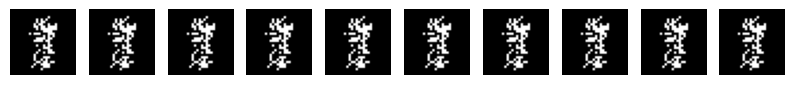

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

latent_dim = 100
img_shape = (28, 28, 1)

def build_generator():
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(latent_dim,)),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(np.prod(img_shape), activation='sigmoid'),
        layers.Reshape(img_shape)
    ])
    return model

generator = build_generator()

def build_discriminator():
    model = keras.Sequential([
        layers.Flatten(input_shape=img_shape),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

discriminator = build_discriminator()

discriminator.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

class GAN(keras.Model):
    def __init__(self, generator, discriminator):
        super(GAN, self).__init__()
        self.generator = generator
        self.discriminator = discriminator

    def compile(self, g_optimizer, d_optimizer, loss_fn):
        super(GAN, self).compile()
        self.g_optimizer = g_optimizer
        self.d_optimizer = d_optimizer
        self.loss_fn = loss_fn

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]

        random_latent_vectors = tf.random.normal(shape=(batch_size, latent_dim))
        generated_images = self.generator(random_latent_vectors)

        real_labels = tf.ones((batch_size, 1))
        fake_labels = tf.zeros((batch_size, 1))

        with tf.GradientTape() as tape:
            real_loss = self.loss_fn(real_labels, self.discriminator(real_images))
            fake_loss = self.loss_fn(fake_labels, self.discriminator(generated_images))
            d_loss = (real_loss + fake_loss) / 2

        d_grads = tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_variables))

        random_latent_vectors = tf.random.normal(shape=(batch_size, latent_dim))
        misleading_labels = tf.ones((batch_size, 1))

        with tf.GradientTape() as tape:
            g_loss = self.loss_fn(misleading_labels, self.discriminator(self.generator(random_latent_vectors)))

        g_grads = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_variables))

        return {"d_loss": d_loss, "g_loss": g_loss}

gan = GAN(generator, discriminator)
gan.compile(
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss_fn=keras.losses.BinaryCrossentropy()
)

(x_train, _), (_, _) = keras.datasets.mnist.load_data()
x_train = (x_train.astype("float32") / 255.0).reshape(-1, 28, 28, 1)

gan.fit(x_train, epochs=50, batch_size=128)

random_latent_vectors = np.random.normal(size=(10, latent_dim))
generated_images = generator.predict(random_latent_vectors)

fig, axes = plt.subplots(1, 10, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(generated_images[i].squeeze(), cmap='gray')
    ax.axis('off')
plt.show()